Problema Resuelto  ¿Qué insights podemos hallar en los datos históricos que nos permitan tomar mejores decisiones antes de efectuar los préstamos?

Datos obtenidos de Kaggle: https://www.kaggle.com/datasets/luishcaldernb/morosidad

Variables: 
1	Mora	Morosidad del cliente: {0: paga al día, 1: cliente moroso}
2	Atraso	Atraso histórico del cliente en días.
3	Vivienda	Tipo de vivienda del cliente.
4	Edad	Edad del cliente.
5	Días_lab	Días laborados en su actual empleo.
6	Exp_sf	Meses con experiencia en el sistema financiero, es decir el número de meses que tiene el cliente desde que adquirió algún producto financiero.
7	Nivel_ahorro	Índice del nivel de ahorro del cliente: {0: no tiene ahorros, 12: alto nivel de ahorros}
8	Ingreso	Ingresos del cliente.
9	Línea_sf	Línea de crédito en el sistema financiero que el cliente tiene disponible.
10	Deuda_sf	Deuda del cliente en el sistema financiero.
11	Score	Calificación crediticia del cliente. Mientras mayor es el score, mejor perfil crediticio tiene el cliente.
12	Zona	Departamento de residencia del cliente.
13	Clasif_sbs	Clasificación SBS. Mientras mayor es el número, peor clasificación tiene el cliente: {0: normal, 1: con problemas potenciales, 2: deficiente, 3: dudoso, 4: pérdida}
14	Nivel_educ	Nivel educativo máximo alcanzado por el cliente.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')
df.head()

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ
0,0,235,FAMILIAR,30,3748,93.0,5,3500.0,NaN,0.00,214,Lima,4,UNIVERSITARIA
1,0,18,FAMILIAR,32,4598,9.0,12,900.0,1824.67,1933.75,175,La Libertad,1,TECNICA
2,0,0,FAMILIAR,26,5148,8.0,2,2400.0,2797.38,188.29,187,Lima,0,UNIVERSITARIA
3,0,0,FAMILIAR,36,5179,20.0,12,2700.0,NaN,0.00,187,Ancash,0,TECNICA
4,0,0,FAMILIAR,46,3960,NaN,1,3100.0,2000.00,11010.65,189,Lima,0,TECNICA


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   str    
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   str    
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   str    
dtypes: float64(4), int64(7), str(3)
memory usage: 1.1 MB


In [3]:
df.describe()

,mora,atraso,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,clasif_sbs
count,8399.000000,8399.00000,8399.000000,8399.000000,6569.000000,8399.000000,8399.000000,7272.000000,7938.000000,8399.000000,8399.000000
mean,0.704251,4.46315,36.399095,5555.888796,32.401583,10.593166,4350.406997,11987.241038,6110.724308,196.619955,0.563519
std,0.456406,14.27084,9.825764,2153.244140,32.866232,3.374619,5367.058953,21322.801655,11177.989799,19.544348,0.905637
min,0.000000,0.00000,20.000000,2956.000000,0.000000,0.000000,123.700000,0.000000,0.000000,134.000000,0.000000
25%,0.000000,0.00000,29.000000,4174.000000,7.000000,12.000000,1366.670000,1169.372500,478.320000,182.000000,0.000000
50%,1.000000,0.00000,34.000000,4904.000000,20.000000,12.000000,2400.000000,4030.120000,2258.755000,197.000000,0.000000
75%,1.000000,2.00000,42.000000,6182.000000,51.000000,12.000000,4900.000000,12086.627500,5755.150000,212.000000,1.000000
max,1.000000,245.00000,85.000000,20700.000000,130.000000,12.000000,30000.000000,121543.400000,57094.380000,266.000000,4.000000


In [4]:
df.isnull().sum()

mora               0
atraso             0
vivienda           0
edad               0
dias_lab           0
exp_sf          1830
nivel_ahorro       0
ingreso            0
linea_sf        1127
deuda_sf         461
score              0
zona               0
clasif_sbs         0
nivel_educ         0
dtype: int64

> Se da el caso de que en las variables experiencia laboral, linea de credito y deuda presenta valores nulos, NaN, esto viene dado por la falta de informacion

In [5]:
(df['exp_sf'] == 0).mean()*100
(df['linea_sf'] == 0).mean()*100
(df['deuda_sf'] == 0).mean()*100

print(f"La media de personas con experiencia laboral cero es: {df['exp_sf'].eq(0).mean()*100:.2f}%")
print(f"La media de personas con saldo de credito cero es: {df['linea_sf'].eq(0).mean()*100:.2f}%")
print(f"La media de personas con deuda cero es: {df['deuda_sf'].eq(0).mean()*100:.2f}%")

La media de personas con experiencia laboral cero es: 14.98%
La media de personas con saldo de credito cero es: 8.89%
La media de personas con deuda cero es: 14.11%


In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['mora',
 'atraso',
 'edad',
 'dias_lab',
 'exp_sf',
 'nivel_ahorro',
 'ingreso',
 'linea_sf',
 'deuda_sf',
 'score',
 'clasif_sbs']

In [7]:
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())
        print(f'Columna "{col}" ahora se ha rellenado con la media de la columna = {df[col].mean():.4f}')

Columna "exp_sf" ahora se ha rellenado con la media de la columna = 32.4016
Columna "linea_sf" ahora se ha rellenado con la media de la columna = 11987.2410
Columna "deuda_sf" ahora se ha rellenado con la media de la columna = 6110.7243


In [8]:
df.isnull().sum()

mora            0
atraso          0
vivienda        0
edad            0
dias_lab        0
exp_sf          0
nivel_ahorro    0
ingreso         0
linea_sf        0
deuda_sf        0
score           0
zona            0
clasif_sbs      0
nivel_educ      0
dtype: int64

> Ahora se puede apreciar que los valores nulos de las diferentes variables del problema han desaperido.

In [9]:
df.describe()

,mora,atraso,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,clasif_sbs
count,8399.000000,8399.00000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000
mean,0.704251,4.46315,36.399095,5555.888796,32.401583,10.593166,4350.406997,11987.241038,6110.724308,196.619955,0.563519
std,0.456406,14.27084,9.825764,2153.244140,29.065550,3.374619,5367.058953,19840.536167,10866.857297,19.544348,0.905637
min,0.000000,0.00000,20.000000,2956.000000,0.000000,0.000000,123.700000,0.000000,0.000000,134.000000,0.000000
25%,0.000000,0.00000,29.000000,4174.000000,10.000000,12.000000,1366.670000,1500.000000,535.150000,182.000000,0.000000
50%,1.000000,0.00000,34.000000,4904.000000,32.401583,12.000000,2400.000000,5523.040000,2518.980000,197.000000,0.000000
75%,1.000000,2.00000,42.000000,6182.000000,39.000000,12.000000,4900.000000,11987.241038,6110.724308,212.000000,1.000000
max,1.000000,245.00000,85.000000,20700.000000,130.000000,12.000000,30000.000000,121543.400000,57094.380000,266.000000,4.000000


Cual es su ratio de endudamiento de los clientes?

In [10]:
df['Endeudamiento'] = df['deuda_sf'] / df['ingreso']
df.head()

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ,Endeudamiento
0,0,235,FAMILIAR,30,3748,93.000000,5,3500.0,11987.241038,0.00,214,Lima,4,UNIVERSITARIA,0.000000
1,0,18,FAMILIAR,32,4598,9.000000,12,900.0,1824.670000,1933.75,175,La Libertad,1,TECNICA,2.148611
2,0,0,FAMILIAR,26,5148,8.000000,2,2400.0,2797.380000,188.29,187,Lima,0,UNIVERSITARIA,0.078454
3,0,0,FAMILIAR,36,5179,20.000000,12,2700.0,11987.241038,0.00,187,Ancash,0,TECNICA,0.000000
4,0,0,FAMILIAR,46,3960,32.401583,1,3100.0,2000.000000,11010.65,189,Lima,0,TECNICA,3.551823


Linea de credito de los clientes respecto a la deuda que poseen, indicador de posibles morosos

In [11]:
df['Indicador_Morosos'] = df['deuda_sf'] > df['linea_sf']

df['Ratio_Deuda_Linea'] = np.where(
    df['Indicador_Morosos'],
    df['deuda_sf'] / df['linea_sf'],
    np.nan
)

df.head()

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ,Endeudamiento,Indicador_Morosos,Ratio_Deuda_Linea
0,0,235,FAMILIAR,30,3748,93.000000,5,3500.0,11987.241038,0.00,214,Lima,4,UNIVERSITARIA,0.000000,False,NaN
1,0,18,FAMILIAR,32,4598,9.000000,12,900.0,1824.670000,1933.75,175,La Libertad,1,TECNICA,2.148611,True,1.059781
2,0,0,FAMILIAR,26,5148,8.000000,2,2400.0,2797.380000,188.29,187,Lima,0,UNIVERSITARIA,0.078454,False,NaN
3,0,0,FAMILIAR,36,5179,20.000000,12,2700.0,11987.241038,0.00,187,Ancash,0,TECNICA,0.000000,False,NaN
4,0,0,FAMILIAR,46,3960,32.401583,1,3100.0,2000.000000,11010.65,189,Lima,0,TECNICA,3.551823,True,5.505325


In [12]:
df['Ratio_Deuda_Linea'].isnull()

0        True
1       False
2        True
3        True
4       False
        ...  
8394     True
8395     True
8396     True
8397     True
8398    False
Name: Ratio_Deuda_Linea, Length: 8399, dtype: bool

In [13]:
df[['Ratio_Deuda_Linea', 'deuda_sf', 'linea_sf']][df['Ratio_Deuda_Linea'].isnull()]

,Ratio_Deuda_Linea,deuda_sf,linea_sf
0,NaN,0.00,11987.241038
2,NaN,188.29,2797.380000
3,NaN,0.00,11987.241038
6,NaN,850.21,4827.640000
8,NaN,0.00,7315.410000
...,...,...,...
8393,NaN,34.08,4426.270000
8394,NaN,8338.46,121543.400000
8395,NaN,0.00,2200.000000
8396,NaN,933.68,10087.000000


> Existen casos en el que la deuda es 0, por eso, se generan esos NaN: En esos casos se hara un boleano para que para cuando el valor de la divisin no sea un nmero entero, al divisor se le haga un +1, para evitarlos.

In [14]:
divisor = np.where(df['linea_sf'] == 0, df['linea_sf'] + 1, df['linea_sf'])
df['Ratio_Deuda_Linea'] = df['deuda_sf'] / divisor
df.head()

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ,Endeudamiento,Indicador_Morosos,Ratio_Deuda_Linea
0,0,235,FAMILIAR,30,3748,93.000000,5,3500.0,11987.241038,0.00,214,Lima,4,UNIVERSITARIA,0.000000,False,0.000000
1,0,18,FAMILIAR,32,4598,9.000000,12,900.0,1824.670000,1933.75,175,La Libertad,1,TECNICA,2.148611,True,1.059781
2,0,0,FAMILIAR,26,5148,8.000000,2,2400.0,2797.380000,188.29,187,Lima,0,UNIVERSITARIA,0.078454,False,0.067309
3,0,0,FAMILIAR,36,5179,20.000000,12,2700.0,11987.241038,0.00,187,Ancash,0,TECNICA,0.000000,False,0.000000
4,0,0,FAMILIAR,46,3960,32.401583,1,3100.0,2000.000000,11010.65,189,Lima,0,TECNICA,3.551823,True,5.505325


Visualizacion de los datos numericos

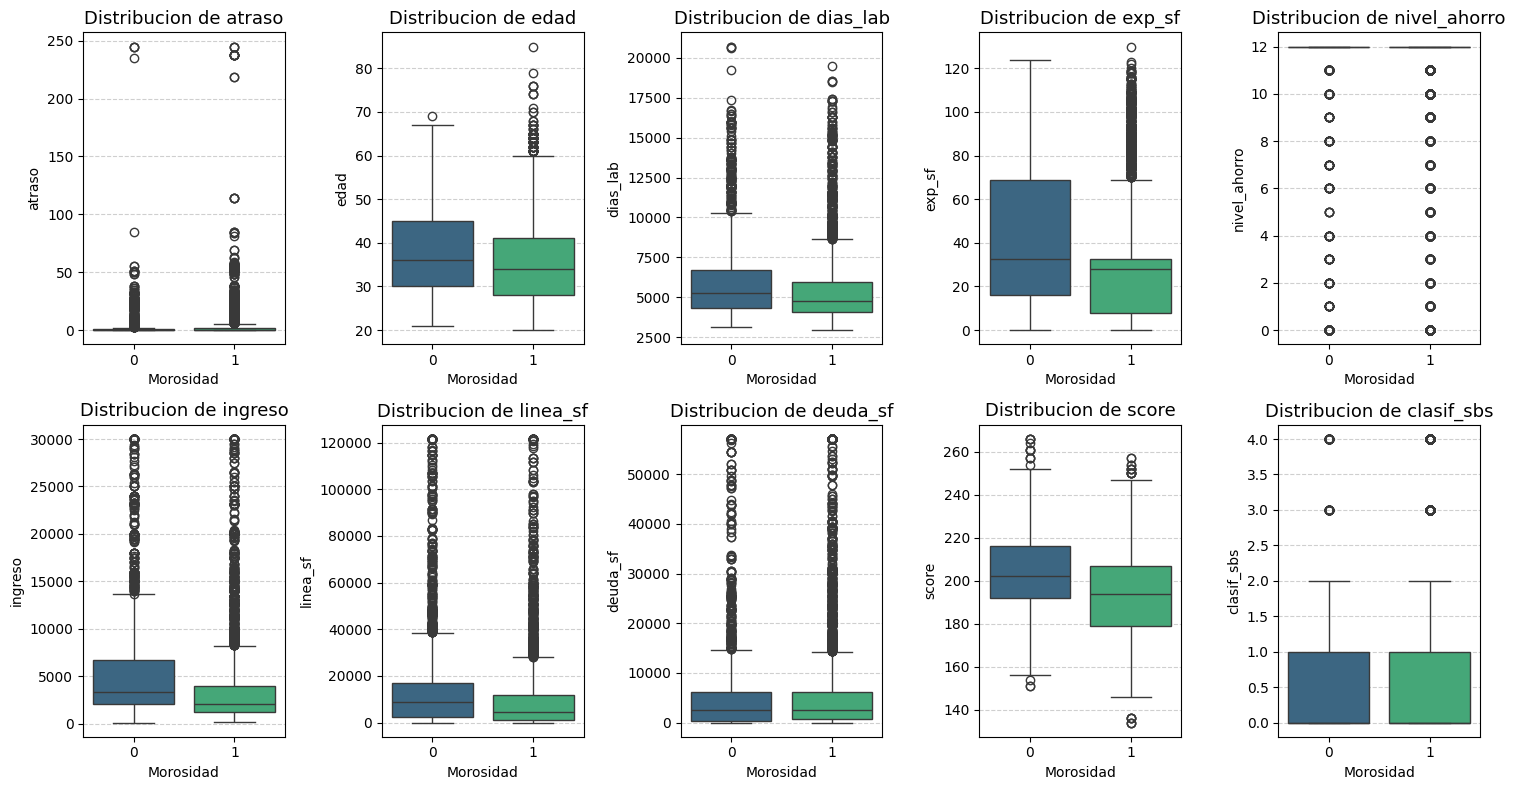

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols_sin_mora = num_cols.copy()
num_cols_sin_mora.remove('mora')

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_sin_mora):
    sns.boxplot(
        data=df,
        x="mora",
        y=col,
        ax=axes[i],
        palette="viridis",
        orient="v",
        hue="mora",
        legend=False
    )
    axes[i].set_title(f"Distribucion de {col}", fontsize=13)
    axes[i].set_xlabel("Morosidad")
    axes[i].set_ylabel(col)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Filtrado de datos outlier mediante 1.5 del rango intercuartilico

In [16]:
df_copia = df.copy()

In [17]:
for col in num_cols:
    Q1 = df[col].quantile(0.25) 
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    Rango_bajo = Q1 - 1.5 * IQR
    Rango_alto = Q3 + 1.5 * IQR 

    df_copia[col] = np.where(df_copia[col] < Rango_bajo, Q1, df_copia[col])
    df_copia[col] = np.where(df_copia[col] > Rango_alto, Q3, df_copia[col])

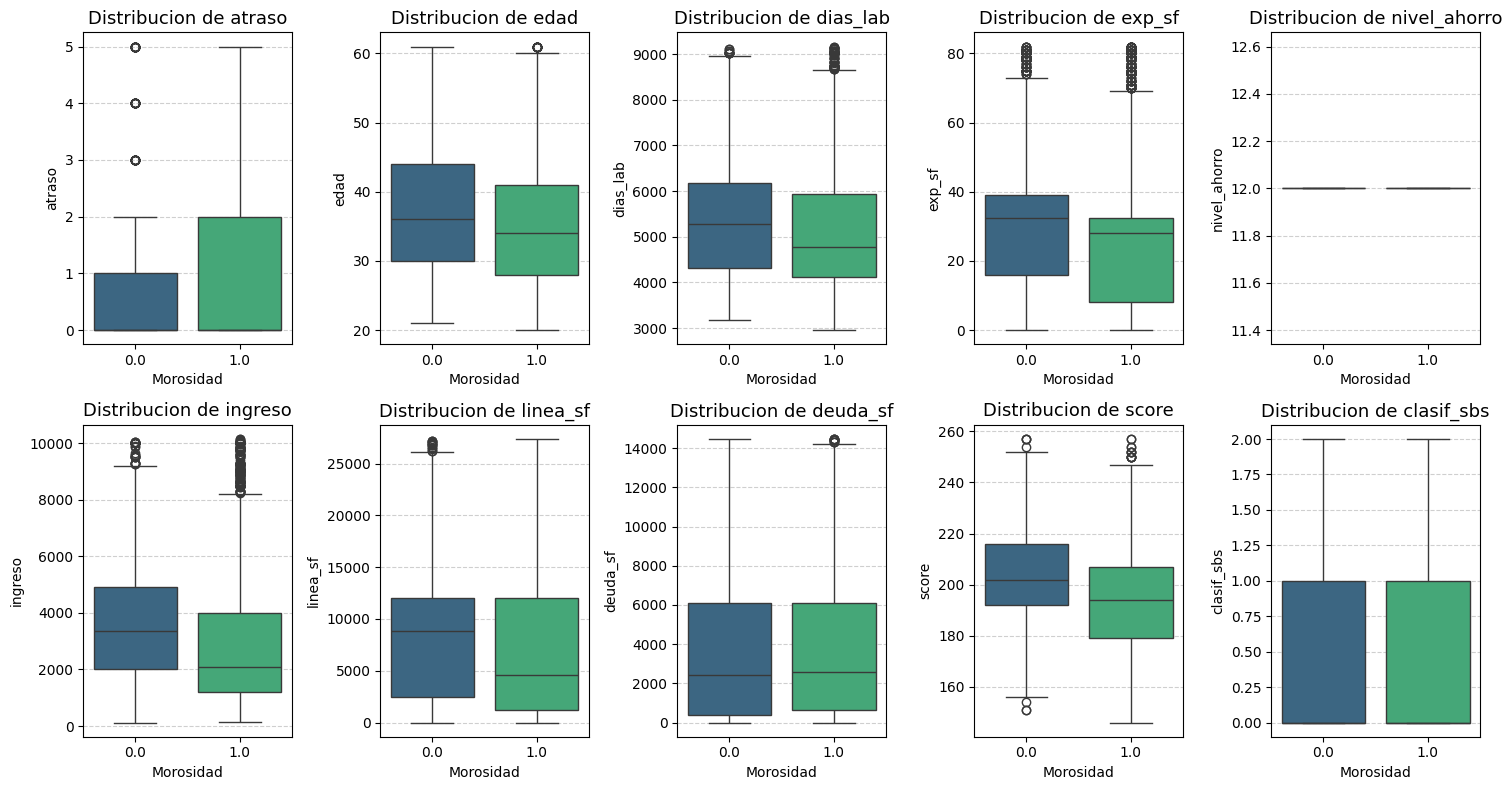

In [18]:
num_cols_sin_mora = num_cols.copy()
num_cols_sin_mora.remove('mora')

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_sin_mora):
    sns.boxplot(
        data=df_copia,
        x="mora",
        y=col,
        ax=axes[i],
        palette="viridis",
        orient="v",
        hue="mora",
        legend=False
    )
    axes[i].set_title(f"Distribucion de {col}", fontsize=13)
    axes[i].set_xlabel("Morosidad")
    axes[i].set_ylabel(col)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

> Se han eliminado notablemente los outliers

In [19]:
df = df_copia.copy()

Normalizacin de ciertas variables

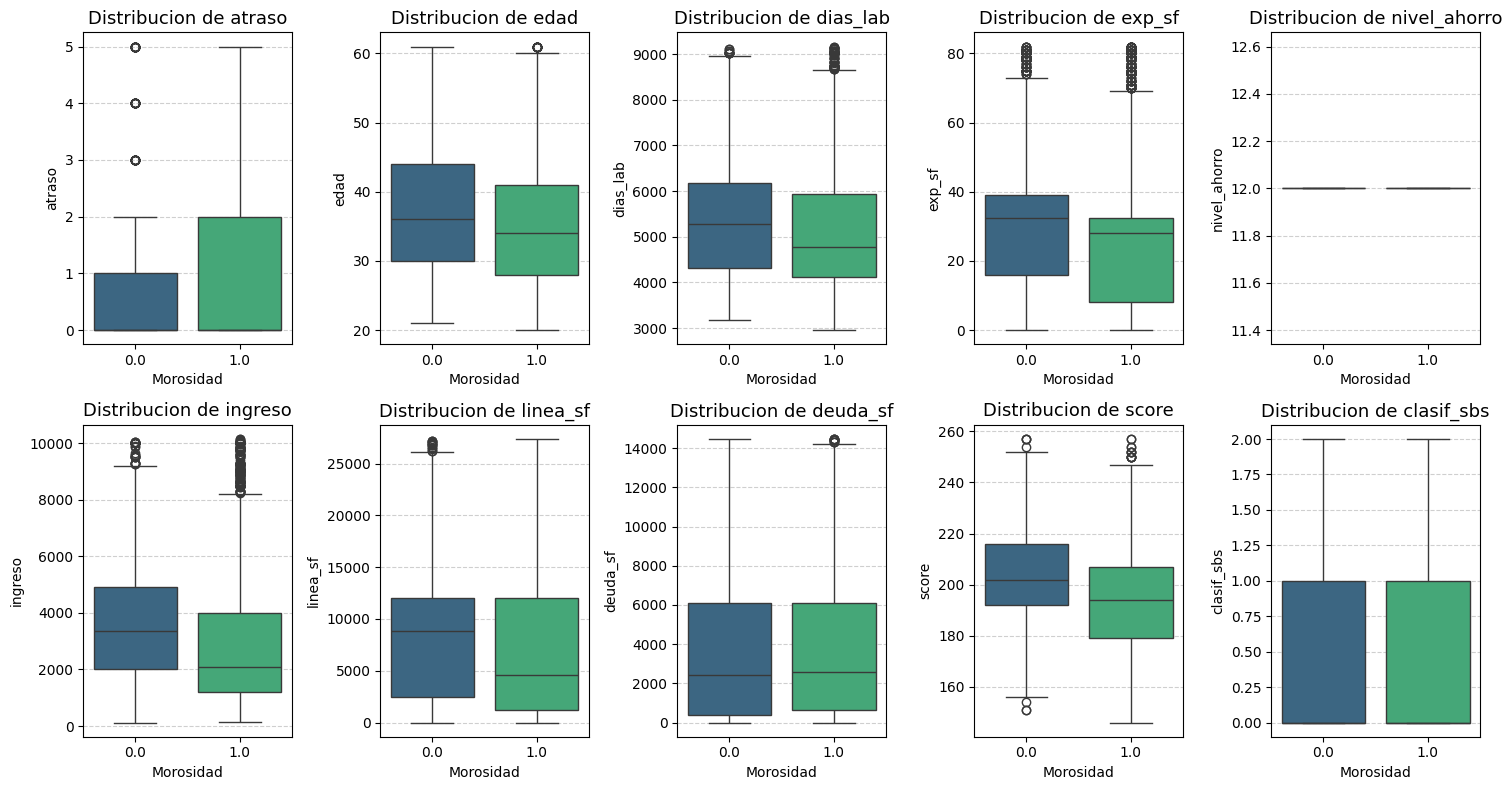

In [20]:
df['ingreso'] = np.sqrt(df['ingreso'])
df['linea_sf'] = np.log(df['linea_sf'] + 1)
df['deuda_sf'] = np.log(df['deuda_sf'] + 1)

num_cols_sin_mora = num_cols.copy()
num_cols_sin_mora.remove('mora')

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_sin_mora):
    sns.boxplot(
        data=df_copia,
        x="mora",
        y=col,
        ax=axes[i],
        palette="viridis",
        orient="v",
        hue="mora",
        legend=False
    )
    axes[i].set_title(f"Distribucion de {col}", fontsize=13)
    axes[i].set_xlabel("Morosidad")
    axes[i].set_ylabel(col)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [21]:
df['nivel_ahorro'].value_counts()

nivel_ahorro
12.0    8399
Name: count, dtype: int64

In [22]:
df.drop(columns=['nivel_ahorro'], inplace=True)

> Se elimina la variable nivel de ahorro, la variable est muy mal informada la mayora de observaciones son 12 y al eliminar outliers nos queda solo el valor 12

Seleccin de todas las variables categoricas

In [23]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11836\80242880.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


['vivienda', 'zona', 'nivel_educ']

In [24]:
for col in cat_cols:
    print(df[col].value_counts())


vivienda
FAMILIAR     5853
PROPIA       2381
ALQUILADA     165
Name: count, dtype: int64
zona
Lima             4980
Callao            507
La Libertad       447
Arequipa          349
Ica               300
Piura             279
Lambayeque        279
Junin             263
Ancash            224
Cajamarca         173
Loreto            118
Cuzco              96
Ucayali            85
Pasco              53
Moquegua           46
San Martin         45
Huanuco            37
Tacna              32
Puno               23
Ayacucho           23
Tumbes             22
Apurimac            8
Madre de Dios       6
Huancavelica        3
Amazonas            1
Name: count, dtype: int64
nivel_educ
UNIVERSITARIA    4802
TECNICA          3288
SECUNDARIA        267
SIN EDUCACION      42
Name: count, dtype: int64


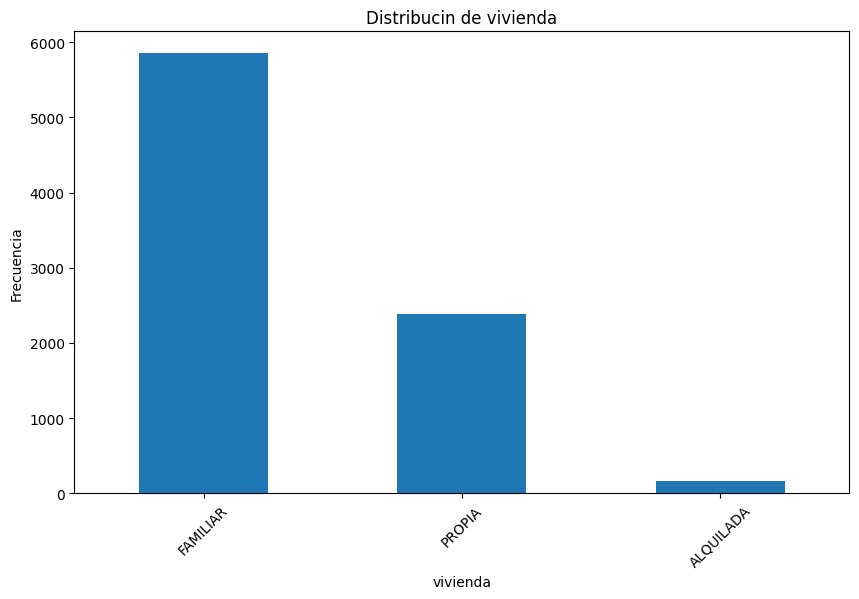

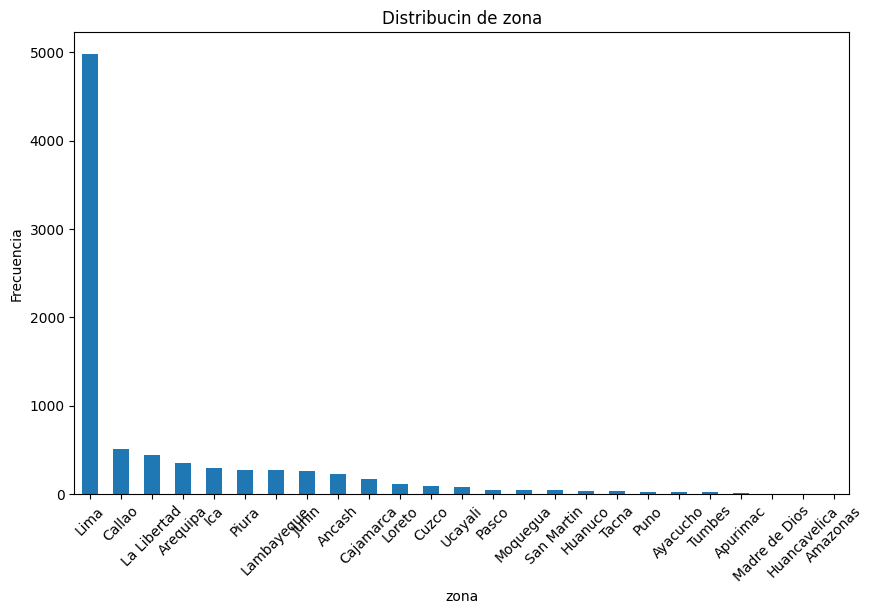

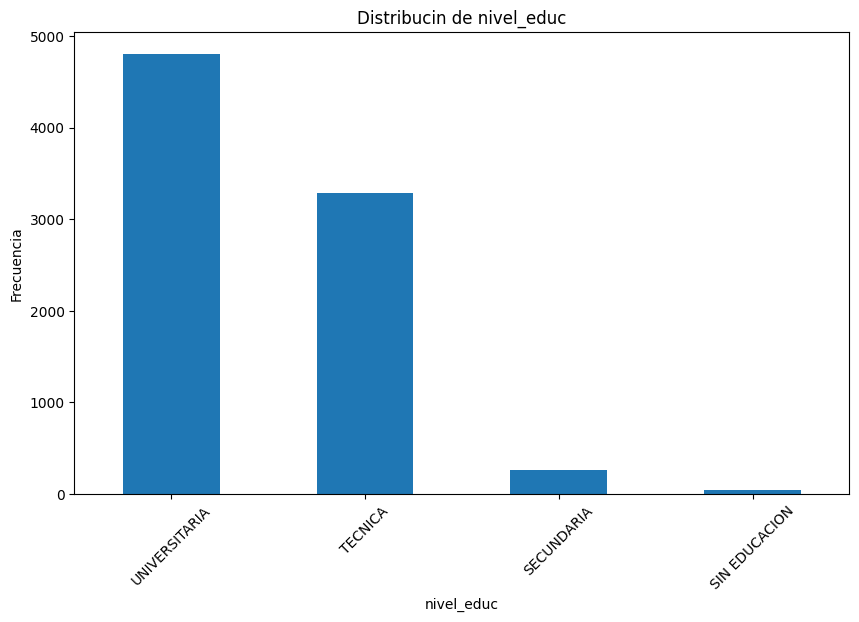

In [25]:
for var in cat_cols:
    plt.figure(figsize=(10, 6))
    df[var].value_counts().plot(kind='bar')
    plt.title(f'Distribucin de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

> No es de inters este tipo de variables categoricas aadir a los modelos, producen mucho ruido y su coste computacional puede llegar a ser muy alto.

In [26]:
df.groupby('zona')['mora'].mean()

zona
Amazonas         1.000000
Ancash           0.772321
Apurimac         0.750000
Arequipa         0.558739
Ayacucho         0.652174
Cajamarca        0.705202
Callao           0.767258
Cuzco            0.666667
Huancavelica     0.333333
Huanuco          0.675676
Ica              0.783333
Junin            0.733840
La Libertad      0.769575
Lambayeque       0.695341
Lima             0.673896
Loreto           0.932203
Madre de Dios    0.833333
Moquegua         0.630435
Pasco            0.849057
Piura            0.853047
Puno             0.739130
San Martin       0.977778
Tacna            0.593750
Tumbes           0.863636
Ucayali          0.894118
Name: mora, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11836\3870134469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zona', y='mora', data=df, palette='viridis')


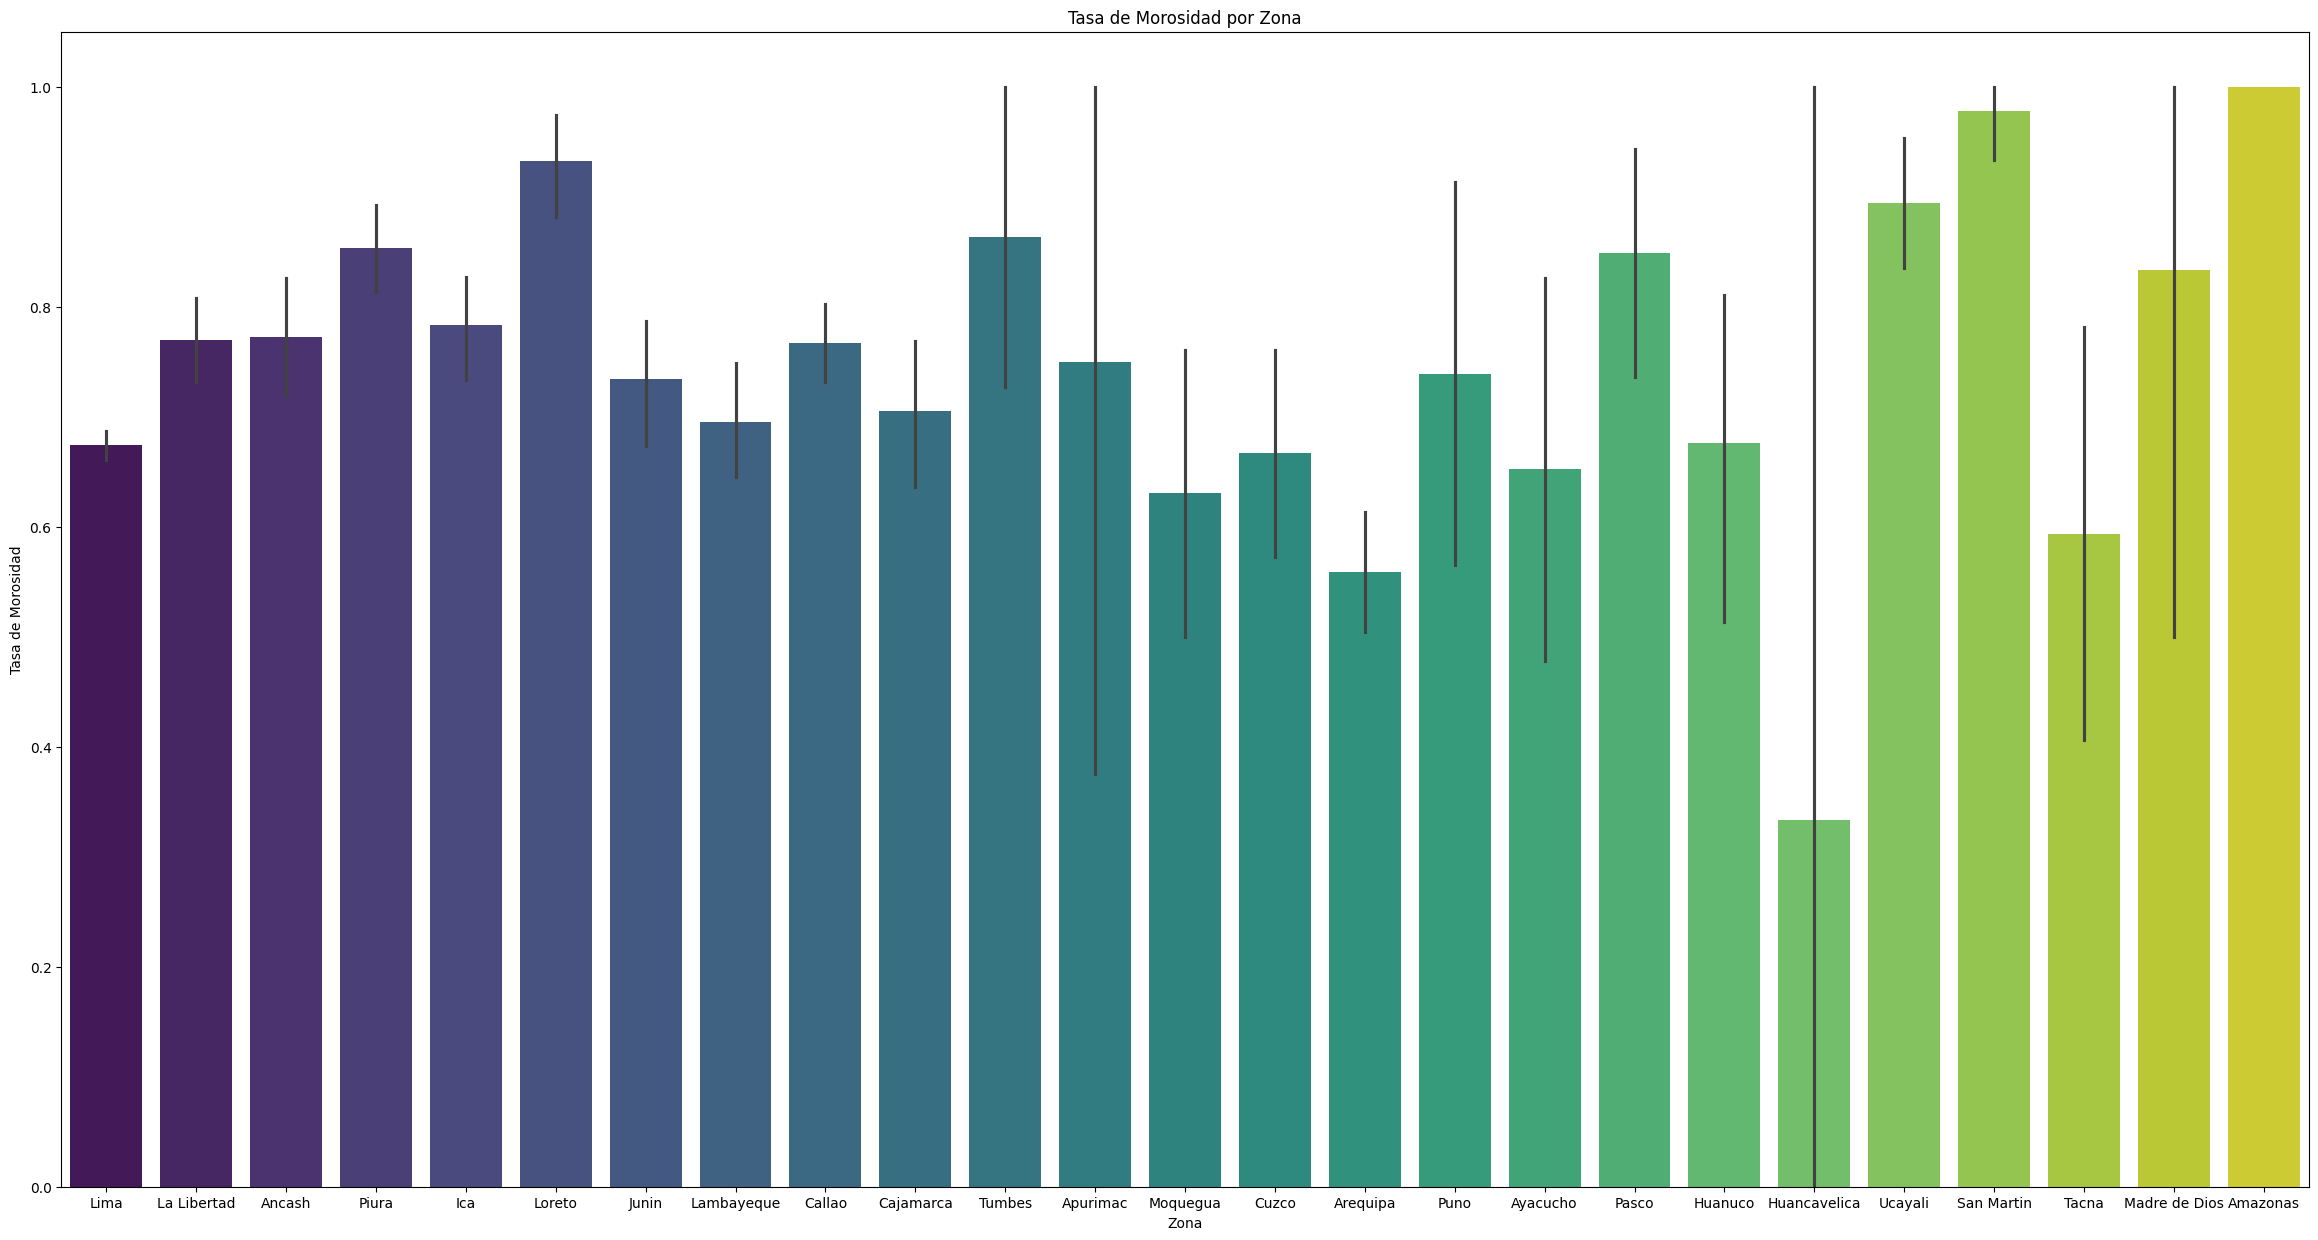

In [27]:
plt.figure(figsize=(29, 15))
sns.barplot(x='zona', y='mora', data=df, palette='viridis')
plt.title('Tasa de Morosidad por Zona')     
plt.xlabel('Zona')
plt.ylabel('Tasa de Morosidad')
plt.show()

In [28]:
df.groupby('zona')['mora'].value_counts().agg(['mean','count'])

mean     171.408163
count     49.000000
Name: count, dtype: float64

In [29]:
df.groupby('zona')['mora'].agg(['mean', 'count']).sort_values('count', ascending=False)


,mean,count
zona,,
Lima,0.673896,4980
Callao,0.767258,507
La Libertad,0.769575,447
Arequipa,0.558739,349
Ica,0.783333,300
Lambayeque,0.695341,279
Piura,0.853047,279
Junin,0.733840,263
Ancash,0.772321,224


Se realiza un filtrado de datos

In [30]:
min_cat = df.shape[0] * 0.05
stats = df.groupby('zona')['mora'].agg(['mean', 'count']).sort_values('count', ascending=False)
cat_superiores = stats[stats['count'] > min_cat].index.tolist()
cat_inferiores = stats[stats['count'] <= min_cat].index.tolist()    
print(f"Categoras con ms del 5% de los datos: {cat_superiores}")
print(f"Categoras con menos del 5% de los datos: {cat_inferiores}")

Categoras con ms del 5% de los datos: ['Lima', 'Callao', 'La Libertad']
Categoras con menos del 5% de los datos: ['Arequipa', 'Ica', 'Lambayeque', 'Piura', 'Junin', 'Ancash', 'Cajamarca', 'Loreto', 'Cuzco', 'Ucayali', 'Pasco', 'Moquegua', 'San Martin', 'Huanuco', 'Tacna', 'Puno', 'Ayacucho', 'Tumbes', 'Apurimac', 'Madre de Dios', 'Huancavelica', 'Amazonas']


In [31]:
cat_inferiores

['Arequipa',
 'Ica',
 'Lambayeque',
 'Piura',
 'Junin',
 'Ancash',
 'Cajamarca',
 'Loreto',
 'Cuzco',
 'Ucayali',
 'Pasco',
 'Moquegua',
 'San Martin',
 'Huanuco',
 'Tacna',
 'Puno',
 'Ayacucho',
 'Tumbes',
 'Apurimac',
 'Madre de Dios',
 'Huancavelica',
 'Amazonas']

Nuevo filtrado de las categorias inferiores acerca de la morosidad

In [32]:
nuevo_umbral = df["mora"].mean()

cat_inf_stats = stats[stats.index.isin(cat_inferiores)]

cat_inferiores_top = cat_inf_stats[cat_inf_stats["mean"] > nuevo_umbral]
cat_inferiores_sub = cat_inf_stats[cat_inf_stats["mean"] <= nuevo_umbral]

print(f"Categorias con tasa de morosidad superior a la media: {cat_inferiores_top}")
print(f"Categorias con tasa de morosidad inferior o igual a la media: {cat_inferiores_sub}")

Categorias con tasa de morosidad superior a la media:                    mean  count
zona                          
Ica            0.783333    300
Piura          0.853047    279
Junin          0.733840    263
Ancash         0.772321    224
Cajamarca      0.705202    173
Loreto         0.932203    118
Ucayali        0.894118     85
Pasco          0.849057     53
San Martin     0.977778     45
Puno           0.739130     23
Tumbes         0.863636     22
Apurimac       0.750000      8
Madre de Dios  0.833333      6
Amazonas       1.000000      1
Categorias con tasa de morosidad inferior o igual a la media:                   mean  count
zona                         
Arequipa      0.558739    349
Lambayeque    0.695341    279
Cuzco         0.666667     96
Moquegua      0.630435     46
Huanuco       0.675676     37
Tacna         0.593750     32
Ayacucho      0.652174     23
Huancavelica  0.333333      3


In [33]:
mapeo = {cat: cat for cat in cat_superiores}
mapeo

{'Lima': 'Lima', 'Callao': 'Callao', 'La Libertad': 'La Libertad'}

In [34]:
for cat in cat_inferiores_top.index:
    mapeo[cat] = "High_Def"

for cat in cat_inferiores_sub.index:
    mapeo[cat] = "Low_Def"

mapeo

{'Lima': 'Lima',
 'Callao': 'Callao',
 'La Libertad': 'La Libertad',
 'Ica': 'High_Def',
 'Piura': 'High_Def',
 'Junin': 'High_Def',
 'Ancash': 'High_Def',
 'Cajamarca': 'High_Def',
 'Loreto': 'High_Def',
 'Ucayali': 'High_Def',
 'Pasco': 'High_Def',
 'San Martin': 'High_Def',
 'Puno': 'High_Def',
 'Tumbes': 'High_Def',
 'Apurimac': 'High_Def',
 'Madre de Dios': 'High_Def',
 'Amazonas': 'High_Def',
 'Arequipa': 'Low_Def',
 'Lambayeque': 'Low_Def',
 'Cuzco': 'Low_Def',
 'Moquegua': 'Low_Def',
 'Huanuco': 'Low_Def',
 'Tacna': 'Low_Def',
 'Ayacucho': 'Low_Def',
 'Huancavelica': 'Low_Def'}

In [35]:
df['zona'] = df['zona'].map(mapeo)
df['zona'].value_counts()

zona
Lima           4980
High_Def       1600
Low_Def         865
Callao          507
La Libertad     447
Name: count, dtype: int64

In [36]:
df.groupby('zona')['mora'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
zona,,
Lima,0.673896,4980
High_Def,0.802500,1600
Low_Def,0.626590,865
Callao,0.767258,507
La Libertad,0.769575,447


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11836\1019892218.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11836\1019892218.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11836\1019892218.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


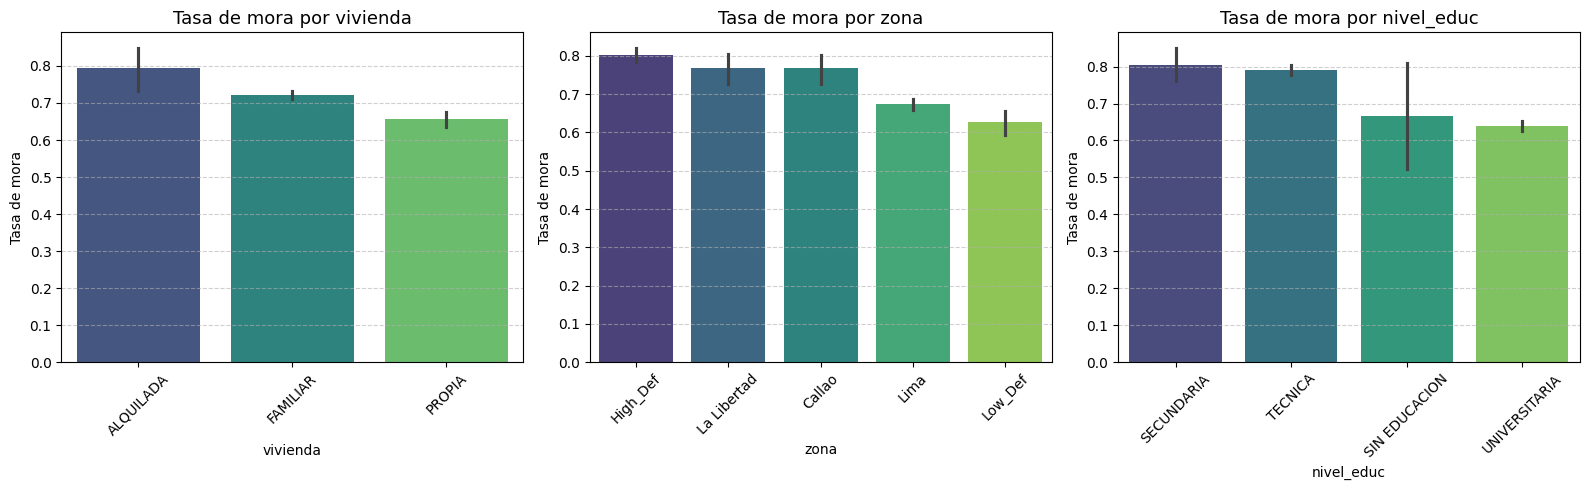

In [37]:
cat_cols = df.select_dtypes(include=["str"]).columns.tolist()

fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(16, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    orden = df.groupby(col)["mora"].mean().sort_values(ascending=False).index
    sns.barplot(
        data=df,
        x=col,
        y="mora",
        order=orden,
        palette="viridis",
        ax=axes[i]
    )
    axes[i].set_title(f"Tasa de mora por {col}", fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tasa de mora")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Variables dummies en las variables categoricas

In [38]:
pd.get_dummies(df, columns=cat_cols, drop_first=True).filter(like="nivel").head()

,nivel_educ_SIN EDUCACION,nivel_educ_TECNICA,nivel_educ_UNIVERSITARIA
0,False,False,True
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False


In [39]:
pd.get_dummies(df, columns=cat_cols, drop_first=True).head().filter(like='nivel').head()

,nivel_educ_SIN EDUCACION,nivel_educ_TECNICA,nivel_educ_UNIVERSITARIA
0,False,False,True
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False


In [40]:
df = pd.get_dummies(df, columns= cat_cols, drop_first=True)
df.head()

,mora,atraso,edad,dias_lab,exp_sf,ingreso,linea_sf,deuda_sf,score,clasif_sbs,...,Ratio_Deuda_Linea,vivienda_FAMILIAR,vivienda_PROPIA,zona_High_Def,zona_La Libertad,zona_Lima,zona_Low_Def,nivel_educ_SIN EDUCACION,nivel_educ_TECNICA,nivel_educ_UNIVERSITARIA
0,0.0,2.0,30.0,3748.0,39.000000,59.160798,9.391682,0.000000,214.0,1.0,...,0.000000,True,False,False,False,True,False,False,False,True
1,0.0,2.0,32.0,4598.0,9.000000,30.000000,7.509702,7.567733,175.0,1.0,...,1.059781,True,False,False,True,False,False,False,True,False
2,0.0,0.0,26.0,5148.0,8.000000,48.989795,7.936796,5.243280,187.0,0.0,...,0.067309,True,False,False,False,True,False,False,False,True
3,0.0,0.0,36.0,5179.0,20.000000,51.961524,9.391682,0.000000,187.0,0.0,...,0.000000,True,False,True,False,False,False,False,True,False
4,0.0,0.0,46.0,3960.0,32.401583,55.677644,7.601402,9.306709,189.0,0.0,...,5.505325,True,False,False,False,True,False,False,True,False


Los modelos pueden dar una mayor importacia a aquellas variables con un valor mas alto, de tal manera que puede corromper el estudio. Para ello, todas las variables deben estar en el mismo rango, es una especie de normalizado. 

El estandarizado se realizara para que tengan una media de 0 y una varianza de 1, mediante la resta de la media entre su respectiva desviacion tipica. 

Se usan librerias para ello sklearn, StandarScaler, MinMAxScaler

In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Recalcular num_cols excluyendo mora (variable objetivo)
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != "mora"]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].head()

,atraso,edad,dias_lab,exp_sf,ingreso,linea_sf,deuda_sf,score,clasif_sbs,Endeudamiento,Ratio_Deuda_Linea
0,1.263003,-0.658683,-1.139341,0.651131,0.361748,0.626091,-2.246839,0.899046,0.872436,-0.389199,-0.051332
1,1.263003,-0.441603,-0.469655,-0.905451,-1.214467,-0.079568,0.302597,-1.116493,0.872436,0.007879,-0.051230
2,-0.710021,-1.092843,-0.036328,-0.957338,-0.188021,0.080574,-0.480470,-0.496327,-0.707467,-0.374700,-0.051326
3,-0.710021,-0.007444,-0.011904,-0.334704,-0.027391,0.626091,-2.246839,-0.496327,-0.707467,-0.389199,-0.051332
4,-0.710021,1.077956,-0.972314,0.308765,0.173474,-0.045184,0.888427,-0.392966,-0.707467,0.267202,-0.050800


In [42]:
df.describe()

,mora,atraso,edad,dias_lab,exp_sf,ingreso,linea_sf,deuda_sf,score,clasif_sbs,Endeudamiento,Ratio_Deuda_Linea
count,8399.000000,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03
mean,0.704251,5.921894e-18,6.767879e-18,-2.910188e-16,1.488933e-16,2.030364e-17,1.624291e-16,-4.060728e-17,4.805194e-16,-2.368758e-17,1.353576e-17,1.015182e-17
std,0.456406,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00
min,0.000000,-7.100208e-01,-1.744083e+00,-1.763332e+00,-1.372426e+00,-2.234868e+00,-2.895374e+00,-2.246839e+00,-2.615226e+00,-7.074671e-01,-3.891986e-01,-5.133214e-02
25%,0.000000,-7.100208e-01,-7.672232e-01,-8.037103e-01,-8.535654e-01,-8.378020e-01,-1.529898e-01,-1.297307e-01,-7.547293e-01,-7.074671e-01,-3.521157e-01,-5.132312e-02
50%,1.000000,-7.100208e-01,-2.245235e-01,-2.285676e-01,3.087652e-01,-1.880208e-01,3.355693e-01,3.916260e-01,2.047775e-02,-7.074671e-01,-1.933358e-01,-5.128785e-02
75%,1.000000,1.263003e+00,6.437960e-01,7.783259e-01,6.511312e-01,9.476337e-01,6.260913e-01,6.900897e-01,7.956848e-01,8.724362e-01,1.360175e-01,-5.117605e-02
max,1.000000,4.222539e+00,2.706055e+00,3.128532e+00,2.882233e+00,2.609061e+00,9.355652e-01,9.805226e-01,3.121306e+00,2.452340e+00,5.456261e+01,6.131257e+01


In [43]:
df.head()

,mora,atraso,edad,dias_lab,exp_sf,ingreso,linea_sf,deuda_sf,score,clasif_sbs,...,Ratio_Deuda_Linea,vivienda_FAMILIAR,vivienda_PROPIA,zona_High_Def,zona_La Libertad,zona_Lima,zona_Low_Def,nivel_educ_SIN EDUCACION,nivel_educ_TECNICA,nivel_educ_UNIVERSITARIA
0,0.0,1.263003,-0.658683,-1.139341,0.651131,0.361748,0.626091,-2.246839,0.899046,0.872436,...,-0.051332,True,False,False,False,True,False,False,False,True
1,0.0,1.263003,-0.441603,-0.469655,-0.905451,-1.214467,-0.079568,0.302597,-1.116493,0.872436,...,-0.051230,True,False,False,True,False,False,False,True,False
2,0.0,-0.710021,-1.092843,-0.036328,-0.957338,-0.188021,0.080574,-0.480470,-0.496327,-0.707467,...,-0.051326,True,False,False,False,True,False,False,False,True
3,0.0,-0.710021,-0.007444,-0.011904,-0.334704,-0.027391,0.626091,-2.246839,-0.496327,-0.707467,...,-0.051332,True,False,True,False,False,False,False,True,False
4,0.0,-0.710021,1.077956,-0.972314,0.308765,0.173474,-0.045184,0.888427,-0.392966,-0.707467,...,-0.050800,True,False,False,False,True,False,False,True,False


Entrenamiento del modelo

In [44]:
from sklearn.model_selection import train_test_split

y = df["mora"]
X = df.drop(columns=["mora"])

print(y)
print(X.head())

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
8394    0.0
8395    1.0
8396    0.0
8397    1.0
8398    0.0
Name: mora, Length: 8399, dtype: float64
     atraso      edad  dias_lab    exp_sf   ingreso  linea_sf  deuda_sf  \
0  1.263003 -0.658683 -1.139341  0.651131  0.361748  0.626091 -2.246839   
1  1.263003 -0.441603 -0.469655 -0.905451 -1.214467 -0.079568  0.302597   
2 -0.710021 -1.092843 -0.036328 -0.957338 -0.188021  0.080574 -0.480470   
3 -0.710021 -0.007444 -0.011904 -0.334704 -0.027391  0.626091 -2.246839   
4 -0.710021  1.077956 -0.972314  0.308765  0.173474 -0.045184  0.888427   

      score  clasif_sbs  Endeudamiento  ...  Ratio_Deuda_Linea  \
0  0.899046    0.872436      -0.389199  ...          -0.051332   
1 -1.116493    0.872436       0.007879  ...          -0.051230   
2 -0.496327   -0.707467      -0.374700  ...          -0.051326   
3 -0.496327   -0.707467      -0.389199  ...          -0.051332   
4 -0.392966   -0.707467       0.267202  ...   

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
X_train.head()

,atraso,edad,dias_lab,exp_sf,ingreso,linea_sf,deuda_sf,score,clasif_sbs,Endeudamiento,...,Ratio_Deuda_Linea,vivienda_FAMILIAR,vivienda_PROPIA,zona_High_Def,zona_La Libertad,zona_Lima,zona_Low_Def,nivel_educ_SIN EDUCACION,nivel_educ_TECNICA,nivel_educ_UNIVERSITARIA
6106,-0.710021,-0.875763,-0.431049,-1.372426,-1.404426,-2.895374,0.647853,0.020478,-0.707467,1.030936,...,0.470097,False,False,False,False,True,False,False,True,False
3063,1.263003,-1.201383,-0.827346,0.308765,-1.266927,0.626091,0.311715,-1.529936,0.872436,0.046514,...,-0.051316,True,False,False,False,True,False,False,True,False
7426,-0.710021,-0.875763,0.347363,0.339815,-0.963608,0.426548,0.416151,-0.444646,0.872436,0.028046,...,-0.051295,True,False,False,False,True,False,False,False,True
1860,-0.710021,-1.418463,-0.851770,-0.801679,-0.359045,-0.564422,-0.164747,-0.082883,-0.707467,-0.346762,...,-0.051239,True,False,True,False,False,False,False,False,True
8048,-0.710021,1.946275,0.778326,-0.853565,1.521811,0.004685,-0.439357,0.433921,-0.707467,-0.383147,...,-0.051323,True,False,False,False,True,False,False,False,True


In [47]:
X_train.shape, X_test.shape, y_test.shape, y_train.shape

((5879, 21), (2520, 21), (2520,), (5879,))

> Coinciden los train y los test. Las dos muestras al coincidir, se podr hacer predicciones coherentes, mismo peso entre ellas.

In [48]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [49]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
model.predict(X_test)

array([1., 1., 1., ..., 1., 0., 1.], shape=(2520,))

Evaluacion de las predicciones

In [52]:
predictions = model.predict(X_test)
(predictions == y_test).mean()

np.float64(0.7103174603174603)

In [53]:
model.score(X_test, y_test)

0.7103174603174603

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

confusion_matrix(y_test, predictions)

array([[ 164,  609],
       [ 121, 1626]])

> De todos los y_test que eran 0 ha captado 164 y se ha confundido en 609; es decir, hay 609 falsos psotivos. 121 clientes que realmente eran morosos pero que el modelo capta como 0, como buenos pagadores. 1626 falsos postivos.


In [55]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.58      0.21      0.31       773
         1.0       0.73      0.93      0.82      1747

    accuracy                           0.71      2520
   macro avg       0.65      0.57      0.56      2520
weighted avg       0.68      0.71      0.66      2520



> De todas las observaciones, la precisin indica una confianza del 73% para captar a clientes morosos, como clientes de confianza un 58%. El recall indica cuantos morosos/clientes de confianza hay respecto al total de morosos/clientes de confianza hay la muestra, destaca ese 93% que detcta de los morosos el modelo. F1_score es la media arimetica entre precision y recall, para compensar por asi decirlo los falsos positivos. 

CURVA ROC

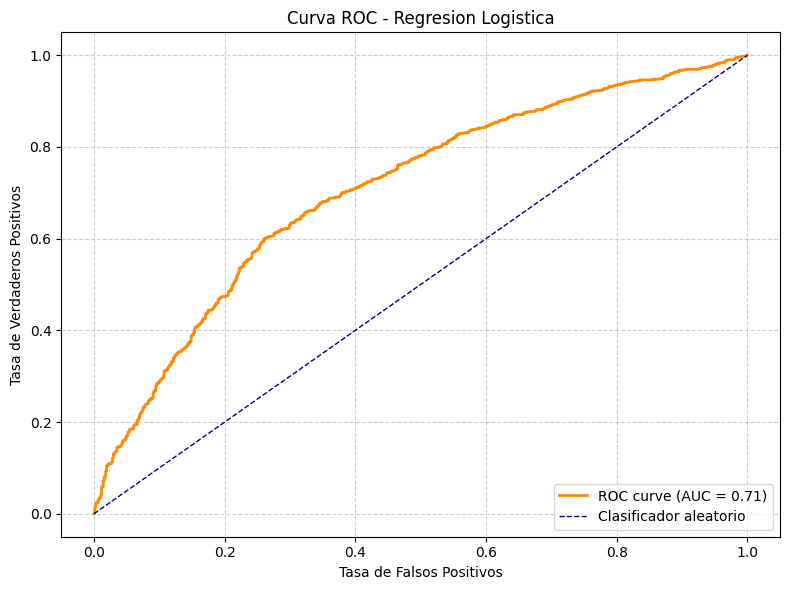

AUC: 0.7067


In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - Regresion Logistica")
plt.legend(loc="lower right")
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
print(f"AUC: {auc:.4f}")

> 71% es comprensible, un indicador de que el modelo no es perfecto.

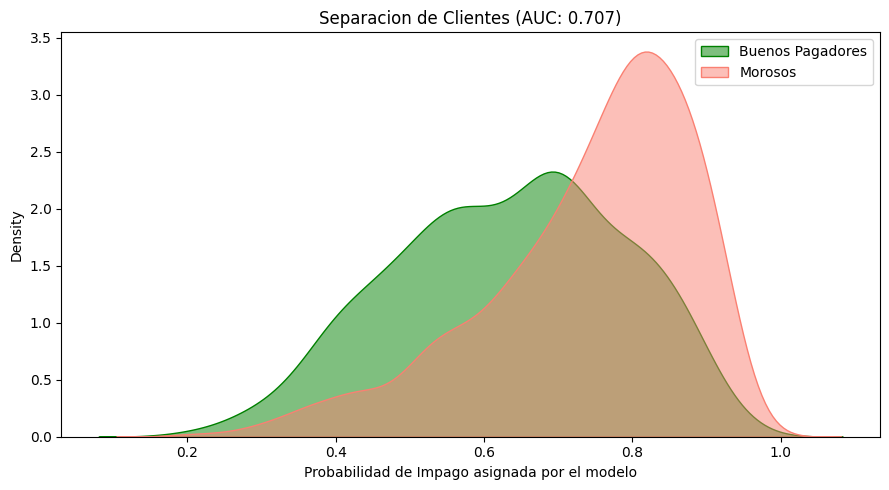

AUC del modelo: 0.7067


In [57]:
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(9, 5))
sns.kdeplot(y_prob[y_test == 0], fill=True, color="green", alpha=0.5, label="Buenos Pagadores")
sns.kdeplot(y_prob[y_test == 1], fill=True, color="salmon", alpha=0.5, label="Morosos")
plt.xlabel("Probabilidad de Impago asignada por el modelo")
plt.ylabel("Density")
plt.title(f"Separacion de Clientes (AUC: {auc:.3f})")
plt.legend()
plt.tight_layout()
plt.show()
print(f"AUC del modelo: {auc:.4f}")

> Para lograr una correlacin notable entre la deteccin de morosos y la deteccin de pocos falsos psotivos se escoge el punto en el que se cortan ambas curvas de densidas. 

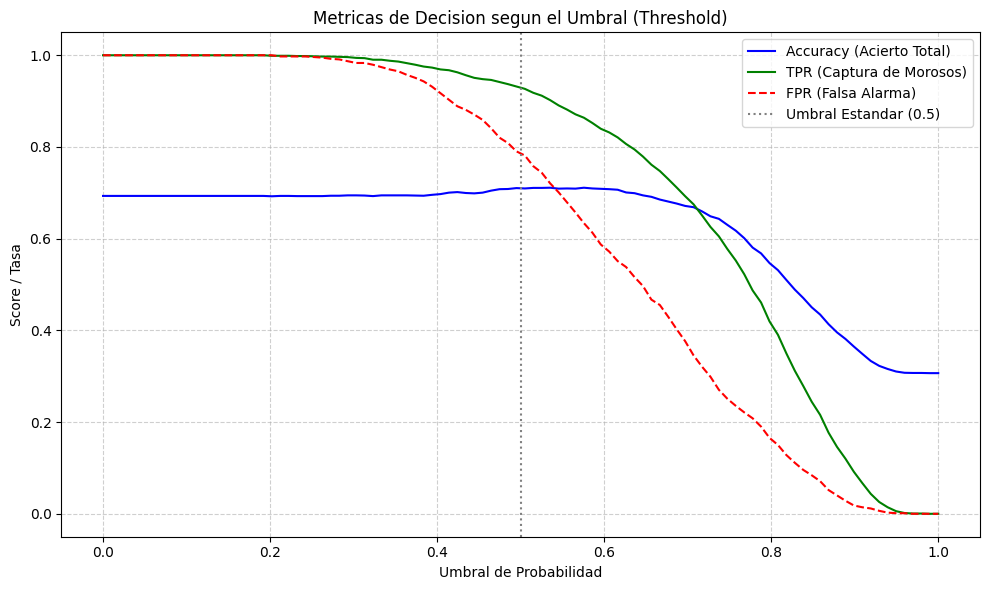

In [58]:
thresholds = np.linspace(0, 1, 100)
accuracy_list, tpr_list, fpr_list = [], [], []

for threshold in thresholds:
    preds = (y_prob >= threshold).astype(int)
    accuracy_list.append((preds == y_test.values).mean())

    tp = ((preds == 1) & (y_test.values == 1)).sum()
    fn = ((preds == 0) & (y_test.values == 1)).sum()
    tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

    fp = ((preds == 1) & (y_test.values == 0)).sum()
    tn = ((preds == 0) & (y_test.values == 0)).sum()
    fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracy_list, color="blue",  label="Accuracy (Acierto Total)")
plt.plot(thresholds, tpr_list,      color="green", label="TPR (Captura de Morosos)")
plt.plot(thresholds, fpr_list,      color="red",   linestyle="--", label="FPR (Falsa Alarma)")

# Identificar puntos de interes
plt.axvline(0.5, color="gray", linestyle=":", label="Umbral Estandar (0.5)")

plt.xlabel("Umbral de Probabilidad")
plt.ylabel("Score / Tasa")
plt.title("Metricas de Decision segun el Umbral (Threshold)")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [59]:
probabilities = model.predict_proba(X_test)
probabilities

array([[0.35203034, 0.64796966],
       [0.34968547, 0.65031453],
       [0.4342789 , 0.5657211 ],
       ...,
       [0.13764047, 0.86235953],
       [0.56408339, 0.43591661],
       [0.44791008, 0.55208992]], shape=(2520, 2))

In [60]:
probabilities = probabilities[:,1]

In [61]:
predictions = (probabilities >= 0.4).astype(int)
predictions[:4]

array([1, 1, 1, 1])

In [62]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.52      0.07      0.13       773
         1.0       0.70      0.97      0.82      1747

    accuracy                           0.69      2520
   macro avg       0.61      0.52      0.47      2520
weighted avg       0.65      0.69      0.60      2520



> Ahora se es ms conservador, por eso sube el recall (ms falsos positivos) y se reduce la precisin

Arbol de decisiones

In [63]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier(random_state = 42)
treemodel.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [64]:
predictions = treemodel.predict(X_test)
predictions[:4]

array([1., 0., 1., 1.])

In [65]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.64      0.63      0.63       773
         1.0       0.84      0.84      0.84      1747

    accuracy                           0.78      2520
   macro avg       0.74      0.74      0.74      2520
weighted avg       0.78      0.78      0.78      2520



> El recall es menor pero detecta un mayor nmero de clientes morosos. Es un modelo menos conservador, ambos modelos pueden ser usados dependiendo del grado de exigencia que se quiera otorgar.

RandomForest

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [67]:
print(classification_report(y_test, rf_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.66      0.19      0.30       773
         1.0       0.73      0.96      0.83      1747

    accuracy                           0.72      2520
   macro avg       0.69      0.57      0.56      2520
weighted avg       0.71      0.72      0.66      2520



In [209]:

modelos = {
    "Logistica": LogisticRegression(),
    "Arbol": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5)
}

resultados = []

for mod in modelos:
    modelo = modelos[mod]
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    report = classification_report(y_test, pred, output_dict=True)
    clase_pos = [k for k in report if k not in ["accuracy", "macro avg", "weighted avg"]][-1]
    resultados.append({
        "Modelo": mod,
        "Accuracy": report["accuracy"],
        "Precision": report[clase_pos]["precision"],
        "Recall": report[clase_pos]["recall"],
        "F1-Score": report[clase_pos]["f1-score"]
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistica,0.710317,0.727517,0.930738,0.816675
1,Arbol,0.746429,0.790966,0.862049,0.824979
2,Random Forest,0.723413,0.725322,0.967373,0.829041


In [208]:
modelos = {
    "Logistica": LogisticRegression(),
    "Arbol": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

resultados = []

for mod in modelos:
    modelo = modelos[mod]
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    report = classification_report(y_test, pred, output_dict=True)
    clase_pos = [k for k in report if k not in ["accuracy", "macro avg", "weighted avg"]][-1]
    resultados.append({
        "Modelo": mod,
        "Accuracy": report["accuracy"],
        "Precision": report[clase_pos]["precision"],
        "Recall": report[clase_pos]["recall"],
        "F1-Score": report[clase_pos]["f1-score"]
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistica,0.710317,0.727517,0.930738,0.816675
1,Arbol,0.744048,0.790612,0.858042,0.822948
2,Random Forest,0.849603,0.839286,0.968517,0.899282


In [211]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100,200], 'max_depth': [None, 5,10,20]}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator = rf_model, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [212]:
grid_search.best_params_

{'max_depth': 20, 'n_estimators': 200}

In [213]:
grid_search.best_score_

np.float64(0.8203776048448987)

In [214]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100,200], 'max_depth': [None, 5,10,20]}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator = rf_model, param_grid=param_grid, cv=3, scoring='recall')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [216]:
grid_search.best_params_

{'max_depth': 5, 'n_estimators': 200}

In [217]:
grid_search.best_score_

np.float64(0.9666511283413873)

In [220]:
pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,0.913096,0.100235,0.055694,0.011314,5,200,"{'max_depth': 5, 'n_estimators': 200}",0.964748,0.971202,0.964003,0.966651,0.003233,1
2,0.471767,0.088573,0.038792,0.012336,5,100,"{'max_depth': 5, 'n_estimators': 100}",0.961151,0.972642,0.965443,0.966412,0.004741,2
5,1.205024,0.079628,0.076975,0.010493,10,200,"{'max_depth': 10, 'n_estimators': 200}",0.956115,0.968323,0.961123,0.961854,0.005010,3
4,0.900864,0.266386,0.044319,0.003834,10,100,"{'max_depth': 10, 'n_estimators': 100}",0.956835,0.966163,0.958963,0.960654,0.003991,4
7,3.052330,0.221657,0.171591,0.012646,20,200,"{'max_depth': 20, 'n_estimators': 200}",0.948201,0.957523,0.956803,0.954176,0.004235,5
6,1.356087,0.172699,0.072407,0.011824,20,100,"{'max_depth': 20, 'n_estimators': 100}",0.946763,0.959683,0.953204,0.953217,0.005275,6
1,2.050300,0.283955,0.122733,0.026704,None,200,"{'max_depth': None, 'n_estimators': 200}",0.944604,0.956084,0.956084,0.952257,0.005411,7
0,0.974629,0.245262,0.073988,0.007297,None,100,"{'max_depth': None, 'n_estimators': 100}",0.941727,0.956803,0.956084,0.951538,0.006944,8


In [221]:
prediction = grid_search.predict(X_test)
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

         0.0       0.66      0.18      0.29       773
         1.0       0.73      0.96      0.83      1747

    accuracy                           0.72      2520
   macro avg       0.69      0.57      0.56      2520
weighted avg       0.71      0.72      0.66      2520

